<a href="https://colab.research.google.com/github/DhimanTarafdar/AAA/blob/main/Inception_V1_V3ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ১. সমস্যার শুরু — আগের Model গুলোতে কী সমস্যা ছিল

আগের বড় model যেমন VGG16 এবং AlexNet এ বড় বড় convolution filter ব্যবহার হতো — যেমন 3x3, 5x5, এমনকি 7x7। যখন একটা layer এ channel সংখ্যা বেশি থাকে এবং filter size বড় হয়, তখন parameter এর সংখ্যা অস্বাভাবিক রকম বেড়ে যায়।

Parameter বেশি হলে তিনটা বড় সমস্যা হয়:

- **Overfitting** — model training data মুখস্থ করে ফেলে, নতুন data তে ভালো কাজ করে না
- **Memory সমস্যা** — GPU তে রাখতে অনেক বেশি memory লাগে
- **Training ধীর হয়** — প্রতিটা epoch এ বেশি computation লাগে
তখন প্রশ্ন আসলো — একই কাজ কি কম parameter এ করা সম্ভব?

---

## ২. Channel মানে কী

RGB image এ 3টা channel থাকে — Red, Green, Blue। প্রতিটা channel একটা আলাদা 2D map যেখানে pixel এর intensity মান থাকে।

Convolution layer দিয়ে feature extract হওয়ার পর output এও channel তৈরি হয়, কিন্তু এগুলো আর RGB না — এগুলো feature map। একটা channel edge detect করে, আরেকটা texture ধরে, আরেকটা shape এর pattern ধরে। Network যত গভীরে যায়, channel গুলো তত complex feature ধরে।

VGG16 এ শেষের দিকে 512টা channel পর্যন্ত চলে যায়।

---

## ৩. VGG16 এর Approach এবং সমস্যা

VGG16 পুরোটা জুড়ে শুধু 3x3 filter ব্যবহার করেছে। দুটো 3x3 filter পরপর দিলে একটা 5x5 filter এর সমান receptive field পাওয়া যায় কিন্তু parameter কম লাগে — এটা ছিল তখনকার নতুন ধারণা।

**কিন্তু সমস্যা হলো channel সংখ্যায়।**

512 channel এ 3x3 filter চালিয়ে 512 channel output চাইলে:
- Parameter = 3 × 3 × 512 × 512 = **2,359,296** — প্রায় ২৩ লাখ শুধু একটা layer এ
এরকম layer অনেকগুলো মিলিয়ে VGG16 এর মোট parameter দাঁড়ায় প্রায় **138 million** (১৩ কোটি ৮০ লাখ)।

**আরেকটা বড় সমস্যা** — প্রতিটা layer এ একটাই নির্দিষ্ট filter size। Network নিজে সিদ্ধান্ত নিতে পারে না যে এই জায়গায় ছোট feature দরকার নাকি বড় feature দরকার।

---

## ৪. ResNet50 এর Approach এবং সীমাবদ্ধতা

ResNet50 ও মূলত 3x3 filter ব্যবহার করে। কিন্তু প্রতিটা Residual Block এ একটা চালাক কাজ আছে — **Bottleneck**।

প্রতিটা block এ তিনটা layer:
1. **1x1 convolution** দিয়ে channel কমাও
2. **3x3 convolution** দিয়ে feature extract করো
3. **1x1 convolution** দিয়ে channel আবার বাড়িয়ে আগের জায়গায় ফেরাও
এই কারণে ResNet50 এর parameter VGG16 এর চেয়ে অনেক কম — প্রায় **25 million**।

**তবুও সীমাবদ্ধতা আছে** — প্রতিটা layer এ filter size আগে থেকে ঠিক করা। Network নিজে বেছে নিতে পারে না।

---

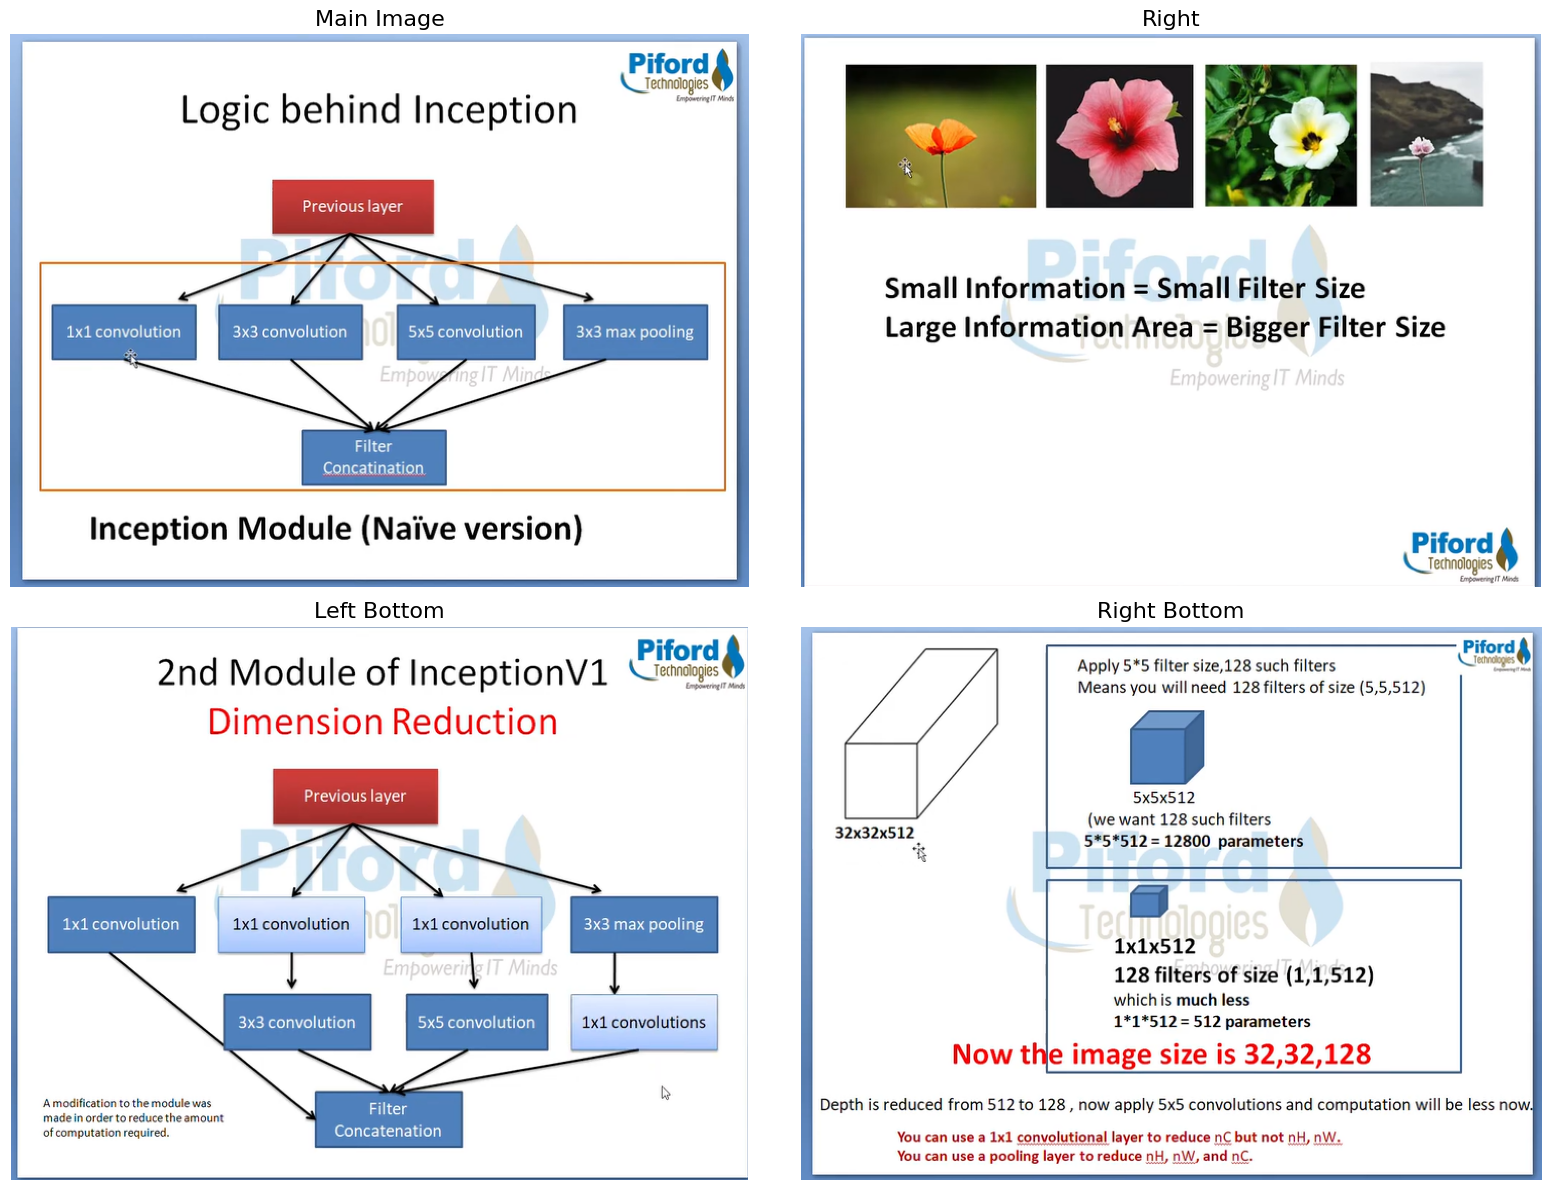

In [4]:
from matplotlib import pyplot as plt
from PIL import Image

# Load images
main_img = Image.open('/content/Screenshot 2026-05-03 231941.png')
right_img = Image.open('/content/Screenshot 2026-05-03 231955.png')
left_bottom_img = Image.open('/content/Screenshot 2026-05-03 232048.png')
right_bottom_img = Image.open('/content/Screenshot 2026-05-03 232112.png')

# Bigger figure size
fig = plt.figure(figsize=(16,12))

# Main image
plt.subplot(2,2,1)
plt.imshow(main_img)
plt.axis('off')
plt.title("Main Image", fontsize=16)

# Right image
plt.subplot(2,2,2)
plt.imshow(right_img)
plt.axis('off')
plt.title("Right", fontsize=16)

# Left bottom image
plt.subplot(2,2,3)
plt.imshow(left_bottom_img)
plt.axis('off')
plt.title("Left Bottom", fontsize=16)

# Right bottom image
plt.subplot(2,2,4)
plt.imshow(right_bottom_img)
plt.axis('off')
plt.title("Right Bottom", fontsize=16)

# Space adjustment
plt.tight_layout()

plt.show()

## ৫. 1x1 Convolution — Inception এর মূল হাতিয়ার

1x1 convolution দেখতে অদ্ভুত মনে হয়, কারণ 1x1 filter দিয়ে spatial feature extract হয় না। কিন্তু এর কাজ আলাদা।

**1x1 convolution এর কাজ হলো channel সংখ্যা কমানো — এটাকে বলে Dimensionality Reduction।**

প্রতিটা pixel এর সব channel এর information একসাথে দেখে একটা নতুন compressed representation তৈরি করে। Information এর সারমর্মটুকু রেখে বাকিটা ছেঁটে ফেলে।

**Parameter তুলনা — 5x5 convolution এর আগে 1x1 বসালে:**

সরাসরি 5x5 (512 → 512 channel):
- Parameter = 5 × 5 × 512 × 512 = **6,553,600** (প্রায় ৬৫ লাখ)
1x1 দিয়ে 512 → 64 channel, তারপর 5x5 (64 → 512 channel):
- 1x1 parameter = 1 × 1 × 512 × 64 = 32,768
- 5x5 parameter = 5 × 5 × 64 × 512 = 819,200
- মোট = **851,968** (প্রায় সাড়ে ৮ লাখ)
**ফলাফল: প্রায় ৮ গুণ কম parameter দিয়ে একই কাজ।**

---

## ৬. Inception V1 — মূল ধারণা এবং Architecture

**মূল সমস্যা যেটা Inception solve করতে চেয়েছে:**

ধরো একটা ছবিতে ছোট পাতা এবং বড় গাছ আছে। ছোট পাতা ধরতে ছোট filter দরকার, বড় গাছ ধরতে বড় filter দরকার। VGG16 এবং ResNet50 একসাথে দুটো করতে পারে না।

**Inception এর সমাধান:** একটা layer এ একসাথে বিভিন্ন size এর filter parallel এ চালাও।

### Inception Module এ কী হয়

একই input একসাথে চারটা আলাদা রাস্তায় যায়:

- **1x1 filter** — ছোট local detail ধরে, channel এর মধ্যে সম্পর্ক দেখে
- **3x3 filter** — মাঝারি আকারের pattern ধরে
- **5x5 filter** — বড় structure এর pattern ধরে
- **MaxPooling** — সবচেয়ে dominant feature টা রাখে, বাকি বাদ দেয়
কিন্তু 3x3 এবং 5x5 filter এর আগে 1x1 convolution বসানো হয় channel কমাতে — এই 1x1 কে বলে **Bottleneck Layer**।

### Output Concatenation — জোড়া লাগানো কীভাবে হয়

চারটা রাস্তার output channel এর দিকে জুড়ে দেওয়া হয় — এটাকে বলে **Concatenation**।

উদাহরণ:
- 1x1 output → 28×28×64
- 3x3 output → 28×28×128
- 5x5 output → 28×28×32
- MaxPool output → 28×28×32
Concatenation এর পর → **28×28×256** (spatial dimension একই, শুধু channel বাড়ে)

### "Best কোনটা" — কে সিদ্ধান্ত নেয়

Inception নিজে থেকে কোনো সিদ্ধান্ত নেয় না। সিদ্ধান্তটা হয় পরের layer এর weight এর মাধ্যমে।

Concatenated feature map পরের layer এ গেলে, backpropagation এ weight update হতে হতে network শিখে নেয় কোন channel বেশি কাজের। যে channel classification এ বেশি সাহায্য করে, তার সাথে connected weight বড় হয়। যে channel কম কাজের, তার weight ছোট হয়ে যায়।

**Network নিজেই শিখে নেয় কোন image এর জন্য কোন filter বেশি দরকার ছিল।**

### Inception V1 এর ফলাফল

এই কারণেই Inception V1 অনেক deep হওয়া সত্ত্বেও parameter সংখ্যা AlexNet বা VGG এর তুলনায় অনেক কম ছিল।

---

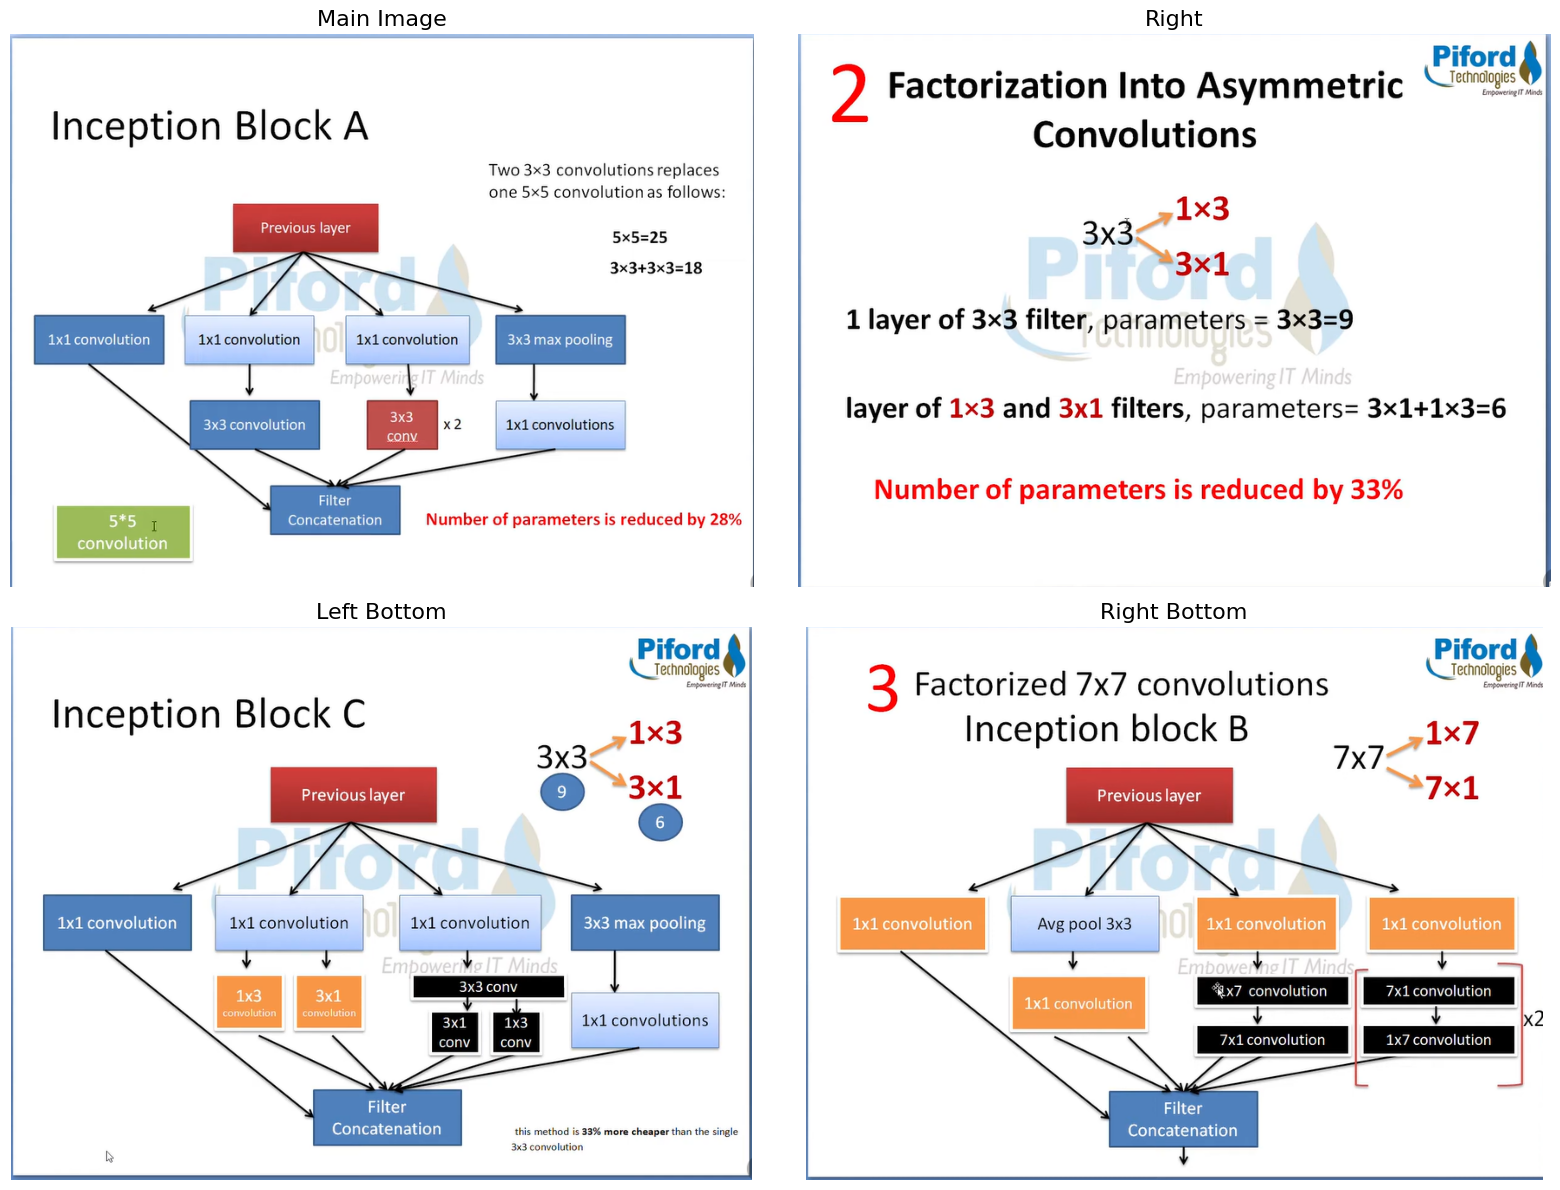

In [5]:
from matplotlib import pyplot as plt
from PIL import Image

# Load images
main_img = Image.open('/content/Screenshot 2026-05-03 233006.png')
right_img = Image.open('/content/Screenshot 2026-05-03 233038.png')
left_bottom_img = Image.open('/content/Screenshot 2026-05-03 233131.png')
right_bottom_img = Image.open('/content/Screenshot 2026-05-03 233142.png')

# Bigger figure size
fig = plt.figure(figsize=(16,12))

# Main image
plt.subplot(2,2,1)
plt.imshow(main_img)
plt.axis('off')
plt.title("Main Image", fontsize=16)

# Right image
plt.subplot(2,2,2)
plt.imshow(right_img)
plt.axis('off')
plt.title("Right", fontsize=16)

# Left bottom image
plt.subplot(2,2,3)
plt.imshow(left_bottom_img)
plt.axis('off')
plt.title("Left Bottom", fontsize=16)

# Right bottom image
plt.subplot(2,2,4)
plt.imshow(right_bottom_img)
plt.axis('off')
plt.title("Right Bottom", fontsize=16)

# Space adjustment
plt.tight_layout()

plt.show()

## ৭. Inception V3 — কী পরিবর্তন হলো এবং কেন

Inception V1 এ যা ছিল তার উপর ভিত্তি করে Inception V3 আরো efficient এবং accurate করা হয়েছে তিনটা মূল technique দিয়ে।

---

## ৮. Inception V3 — Technique 1: Factorization into Smaller Convolutions

**সমস্যা:** V1 এ 5x5 filter ব্যবহার হতো। 5x5 filter এ parameter সংখ্যা = 5 × 5 = **25**।

**সমাধান:** 5x5 filter কে ভেঙে দুটো 3x3 filter বানাও।

দুটো 3x3 filter এর parameter = 3×3 + 3×3 = **18**।

এই দুটো 3x3 filter পরপর চালালে 5x5 এর সমান receptive field পাওয়া যায়, কিন্তু parameter কমে যায় **28%**।

এই block কে বলা হয় **Inception Block A**।

---

## ৯. Inception V3 — Technique 2: Factorization into Asymmetric Convolutions

**সমস্যা:** 3x3 filter এ parameter = 3 × 3 = **9**।

**সমাধান:** 3x3 filter কে ভেঙে দুটো asymmetric filter বানাও — একটা 1x3 এবং একটা 3x1।

1x3 + 3x1 এর parameter = 3 + 3 = **6**।

Parameter কমে যায় **33%**।

এই একই technique 7x7 filter এর ক্ষেত্রেও প্রযোজ্য — 7x7 কে ভাঙা হয় 1x7 এবং 7x1 এ।

V3 তে তিনটা আলাদা block আছে:

- **Inception Block A** — 5x5 কে দুটো 3x3 এ ভাঙা
- **Inception Block B** — 7x7 কে 1x7 এবং 7x1 asymmetric convolution এ ভাঙা
- **Inception Block C** — 3x3 কে 1x3 এবং 3x1 asymmetric convolution এ ভাঙা
---

## ১০. Inception V3 — Technique 3: Auxiliary Classifiers (Vanishing Gradient সমস্যার সমাধান)

**সমস্যা:** Network অনেক deep হলে backpropagation এ gradient শুরুর layer পর্যন্ত পৌঁছাতে পৌঁছাতে অনেক ছোট হয়ে যায় — এটাকে বলে **Vanishing Gradient**। ফলে শুরুর layer গুলো ঠিকমতো শিখতে পারে না।

**সমাধান:** Network এর মাঝখানে **Auxiliary Classifier** বসানো।

Auxiliary classifier হলো একটা intermediate classification layer যেটা training এর সময় মাঝখান থেকে loss calculate করে। এই loss টা main classification loss এর সাথে যোগ করা হয়।

এতে gradient শুধু শেষ layer থেকে না এসে মাঝ থেকেও আসে, ফলে শুরুর layer গুলোতে gradient পৌঁছায় এবং তারাও শিখতে পারে।

**গুরুত্বপূর্ণ:** Auxiliary classifier শুধু training এ কাজ করে। Final prediction সবসময় শেষের softmax classifier করে। Auxiliary classifier এর কোনো prediction এ ভূমিকা নেই।

---

## ১১. Inception V3 — Layer Architecture সংক্ষেপে

Input size: **299 × 299 × 3** (colored image)

Network এর ধাপগুলো:
1. তিনটা Convolutional layer (3x3 filter, stride 2 এবং 1)
2. Max Pool layer
3. আরো Convolutional layer (1x1 এবং 3x3 filter)
4. Max Pool layer
5. **Inception Block A — 3 বার**
6. Reduction Block A (dimension কমায়)
7. **Inception Block B — 4 বার**
8. Reduction Block B (dimension কমায়)
9. **Inception Block C — 2 বার**
10. Global Average Pooling
11. Auxiliary Classifier (training এর জন্য)
12. Final Dense layer → **1000 neurons** (Softmax)
মোট layer: **48 layers**
Training dataset: ImageNet — **1000 classes**

---

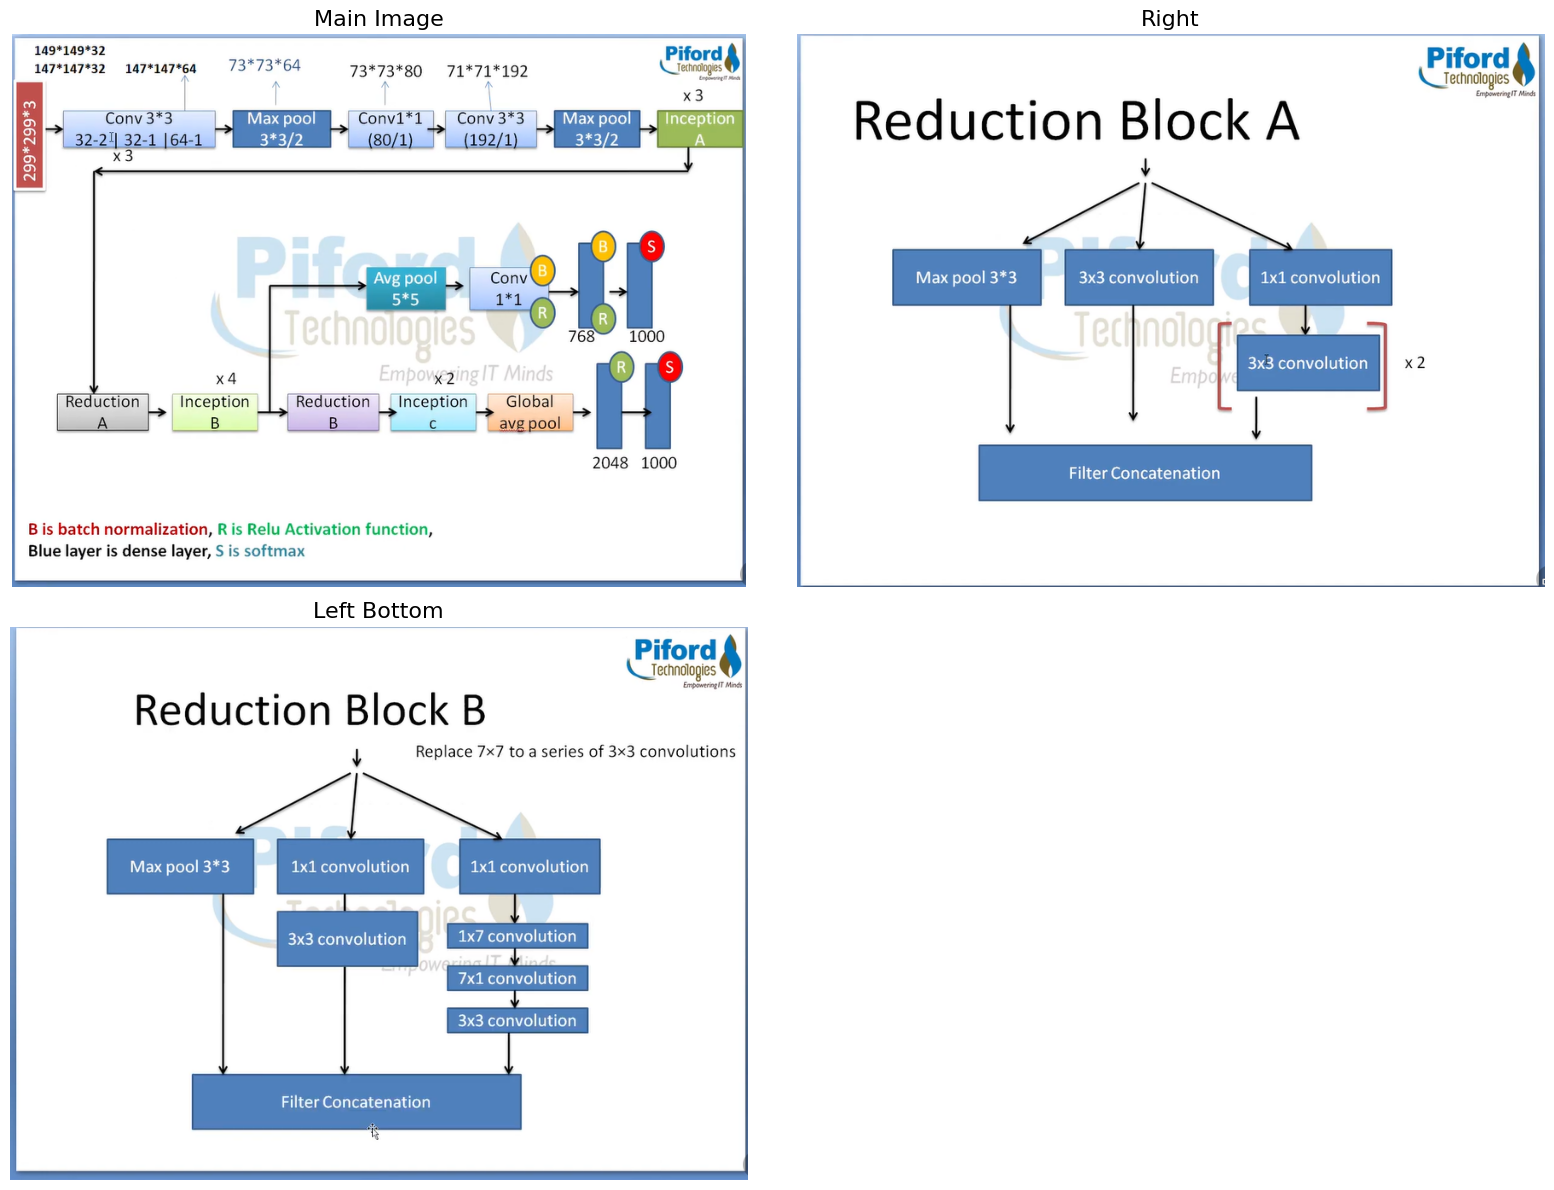

In [6]:
from matplotlib import pyplot as plt
from PIL import Image

# Load images
main_img = Image.open('/content/Screenshot 2026-05-03 233155.png')
right_img = Image.open('/content/Screenshot 2026-05-03 233228.png')
left_bottom_img = Image.open('/content/Screenshot 2026-05-03 233235.png')

# Bigger figure size
fig = plt.figure(figsize=(16,12))

# Main image
plt.subplot(2,2,1)
plt.imshow(main_img)
plt.axis('off')
plt.title("Main Image", fontsize=16)

# Right image
plt.subplot(2,2,2)
plt.imshow(right_img)
plt.axis('off')
plt.title("Right", fontsize=16)

# Left bottom image
plt.subplot(2,2,3)
plt.imshow(left_bottom_img)
plt.axis('off')
plt.title("Left Bottom", fontsize=16)


# Space adjustment
plt.tight_layout()

plt.show()

## ১২. Reduction Block — কী করে

Reduction Block গুলো Inception block গুলোর মাঝে থাকে। এর কাজ হলো feature map এর spatial dimension কমানো (height এবং width ছোট করা) এবং সাথে parameter ও কমানো।

- **Reduction Block A** — 5x5 কে দুটো 3x3 এ ভেঙে এবং MaxPool দিয়ে dimension কমায়
- **Reduction Block B** — 7x7 কে asymmetric convolution এ ভেঙে এবং 3x3 convolution দিয়ে dimension কমায়
---

## ১৩. VGG16, ResNet50, Inception V1, Inception V3 — তুলনা

| বিষয় | VGG16 | ResNet50 | Inception V1 | Inception V3 |
|---|---|---|---|---|
| Parameter সংখ্যা | ~138M | ~25M | ~7M | ~24M |
| Filter type | শুধু 3x3 | 1x1, 3x3 | 1x1, 3x3, 5x5 parallel | Asymmetric + Parallel |
| একসাথে বিভিন্ন feature | না | না | হ্যাঁ | হ্যাঁ |
| Vanishing gradient সমাধান | না | Skip connection | না | Auxiliary classifier |
| Input size | 224×224 | 224×224 | 224×224 | 299×299 |

---

## ১৪. সারসংক্ষেপ — মূল শিক্ষা

Inception এর পুরো যাত্রার মূল কথা তিনটা:

**প্রথম:** বড় filter এর আগে 1x1 convolution বসিয়ে channel কমিয়ে দাও, তারপর বড় filter চালাও — parameter অনেক কম লাগে।

**দ্বিতীয়:** একই layer এ parallel এ ছোট, মাঝারি এবং বড় — তিন ধরনের filter চালাও — network নিজেই শিখে নেবে কোনটা বেশি দরকার।

**তৃতীয়:** বড় filter কে ছোট filter এ ভাঙো (5x5 → দুটো 3x3, বা 3x3 → 1x3 + 3x1) — একই receptive field কিন্তু আরো কম parameter।

এই তিনটা ধারণাই Inception কে আগের সব model এর চেয়ে efficient এবং accurate করে তুলেছে।

In [1]:
# Install kagglehub if not already installed
!pip install kagglehub -q

In [2]:

import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, datasets, models
from torch.utils.data import DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import kagglehub

In [3]:
import kagglehub

# PlantVillage dataset download
path = kagglehub.dataset_download("mohitsingh1804/plantvillage")
print("Dataset Path:", path)

TRAIN_PATH = os.path.join(path, "PlantVillage", "train")
VAL_PATH   = os.path.join(path, "PlantVillage", "val")

classes     = os.listdir(TRAIN_PATH)
num_classes = len(classes)
print(f"Total Classes: {num_classes}")
print(f"Classes: {classes[:5]} ...")  # প্রথম ৫টা দেখাবে

# প্রতিটা class এ কতটা image
for cls in sorted(classes):
    count = len(os.listdir(os.path.join(TRAIN_PATH, cls)))
    print(f"  {cls}: {count} images")

Using Colab cache for faster access to the 'plantvillage' dataset.
Dataset Path: /kaggle/input/plantvillage
Total Classes: 38
Classes: ['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy'] ...
  Apple___Apple_scab: 504 images
  Apple___Black_rot: 496 images
  Apple___Cedar_apple_rust: 220 images
  Apple___healthy: 1316 images
  Blueberry___healthy: 1202 images
  Cherry_(including_sour)___Powdery_mildew: 842 images
  Cherry_(including_sour)___healthy: 684 images
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 410 images
  Corn_(maize)___Common_rust_: 953 images
  Corn_(maize)___Northern_Leaf_Blight: 788 images
  Corn_(maize)___healthy: 929 images
  Grape___Black_rot: 944 images
  Grape___Esca_(Black_Measles): 1107 images
  Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 861 images
  Grape___healthy: 339 images
  Orange___Haunglongbing_(Citrus_greening): 4405 images
  Peach___Bacterial_spot: 1838 images
  Peach_

# **Step 3 — Library Import এবং Configuration**

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

# ---- Configuration ----
# MODEL_VERSION = "v1"  → GoogLeNet  (input: 224x224)
# MODEL_VERSION = "v3"  → Inception V3 (input: 299x299)

MODEL_VERSION = "v1"      # এখানে "v1" বা "v3" দাও
BATCH_SIZE    = 32
EPOCHS        = 10
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device       : {DEVICE}")
print(f"Model        : Inception {MODEL_VERSION.upper()}")
print(f"Num Classes  : {num_classes}")

Device       : cuda
Model        : Inception V1
Num Classes  : 38


# **Step 4 — Transform এবং DataLoader**

In [5]:
IMG_SIZE = 224 if MODEL_VERSION == "v1" else 299

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=TRAIN_PATH, transform=train_transform)
val_dataset   = datasets.ImageFolder(root=VAL_PATH,   transform=val_transform)

train_loader  = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                           shuffle=True,  num_workers=2)
val_loader    = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                           shuffle=False, num_workers=2)

CLASS_NAMES = train_dataset.classes
print(f"Train samples : {len(train_dataset)}")
print(f"Val samples   : {len(val_dataset)}")
print(f"Classes       : {CLASS_NAMES[:3]} ...")

Train samples : 43444
Val samples   : 10861
Classes       : ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust'] ...


# **Step 5 — Model**

In [6]:
def get_model(version, num_classes):
    if version == "v1":
        model = models.googlenet(pretrained=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        print(f"Inception V1 (GoogLeNet) loaded — input: 224x224")

    elif version == "v3":
        model = models.inception_v3(pretrained=True)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        model.AuxLogits.fc = nn.Linear(
            model.AuxLogits.fc.in_features, num_classes
        )
        print(f"Inception V3 loaded — input: 299x299")

    else:
        raise ValueError("version must be 'v1' or 'v3'")

    return model

model = get_model(MODEL_VERSION, num_classes).to(DEVICE)

Downloading: "https://download.pytorch.org/models/googlenet-1378be20.pth" to /root/.cache/torch/hub/checkpoints/googlenet-1378be20.pth


100%|██████████| 49.7M/49.7M [00:00<00:00, 133MB/s]


Inception V1 (GoogLeNet) loaded — input: 224x224


# **Step 6 — Train এবং Validation Function**

In [7]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()

        outputs = model(images)

        # Inception V3 training এ (main, aux) tuple আসে
        if isinstance(outputs, tuple):
            main_out, aux_out = outputs
            loss    = criterion(main_out, labels) + 0.4 * criterion(aux_out, labels)
            outputs = main_out
        else:
            loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total   += labels.size(0)

    return total_loss / len(loader), 100 * correct / total


def validate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)

            if isinstance(outputs, tuple):
                outputs = outputs[0]

            loss = criterion(outputs, labels)
            total_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total   += labels.size(0)

    return total_loss / len(loader), 100 * correct / total

# **Step 7 — Training Loop**

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)

history = {"train_loss": [], "train_acc": [],
           "val_loss":   [], "val_acc":   []}
best_val_acc = 0.0

print(f"\n{'Epoch':>6} | {'Train Loss':>10} | {'Train Acc':>9} | {'Val Loss':>8} | {'Val Acc':>8}")
print("-" * 58)

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_acc   = validate(model, val_loader, criterion)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"{epoch:>6} | {train_loss:>10.4f} | {train_acc:>8.2f}% | "
          f"{val_loss:>8.4f} | {val_acc:>7.2f}%", end="")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), f"best_inception_{MODEL_VERSION}.pth")
        print("  ✓ saved", end="")

    print()

print(f"\nBest Validation Accuracy: {best_val_acc:.2f}%")

# **Step 8 — Loss এবং Accuracy Plot**

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], label="Train Loss", marker="o")
axes[0].plot(epochs_range, history["val_loss"],   label="Val Loss",   marker="o")
axes[0].set_title(f"Inception {MODEL_VERSION.upper()} — Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs_range, history["train_acc"], label="Train Acc", marker="o")
axes[1].plot(epochs_range, history["val_acc"],   label="Val Acc",   marker="o")
axes[1].set_title(f"Inception {MODEL_VERSION.upper()} — Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy (%)")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(f"training_plot_{MODEL_VERSION}.png", dpi=150)
plt.show()

# **Step 9 — নতুন Image দিয়ে Predict করো**

In [ ]:
from PIL import Image

def predict(image_path, model, transform, class_names, top_k=3):
    model.eval()
    image        = Image.open(image_path).convert("RGB")
    input_tensor = transform(image).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        output = model(input_tensor)
        if isinstance(output, tuple):
            output = output[0]
        probs = torch.softmax(output, dim=1)[0]

    top_probs, top_idxs = torch.topk(probs, top_k)

    print(f"\nImage: {image_path}")
    print(f"Top {top_k} Predictions:")
    for i in range(top_k):
        cls  = class_names[top_idxs[i].item()]
        prob = top_probs[i].item() * 100
        bar  = "█" * int(prob / 5)
        print(f"  {i+1}. {cls:40s} {prob:5.1f}%  {bar}")

# Best model load করে predict করো
model.load_state_dict(torch.load(f"best_inception_{MODEL_VERSION}.pth"))

# তোমার test image path দাও
predict("test_leaf.jpg", model, val_transform, CLASS_NAMES)

# **V1 থেকে V3 তে Switch**

In [ ]:
# Step 3 এ শুধু এটা বদলাও — বাকি সব automatically ঠিক হয়ে যাবে
MODEL_VERSION = "v3"